In [1]:
import torch
from collections import OrderedDict  #这个类是字典dict的一个子类，用于创建有序的字典。普通字典中元素顺序是无序的，在OrderedDict中元素的顺序是有序的，元素的顺序是按照它们被添加到字典中的顺序决定的。
from pyDOE import lhs 
import numpy as np
import matplotlib.pyplot as plt
import scipy.io #导入了scipy库中的io模块。scipy.io模块包含了一些用于文件输入/输出的函数，例如读取和写入.mat文件（MATLAB格式）
from scipy.interpolate import griddata #`scipy.interpolate`是`scipy`库中的一个模块，提供了许多插值工具，用于在给定的离散数据点之间进行插值和拟合。`griddata`是这个模块中的一个函数，用于在无规则的数据点上进行插值。
import random
import skopt #用于优化问题的库，特别是机器学习中的超参数优化
from distutils.version import LooseVersion #distutils是Python的一个标准库，用于构建和安装Python包。LooseVersion是一个类，用于比较版本号
from mpl_toolkits.axes_grid1 import make_axes_locatable #`mpl_toolkits.axes_grid1`是`matplotlib`库的一个模块，提供了一些高级的工具来控制matplotlib图形中的坐标轴和颜色条。`make_axes_locatable`是模块中的一个函数，用于创建一个可分割的坐标轴。可以在这个坐标轴的四个方向（上、下、左、右）添加新的坐标轴或颜色条。
import matplotlib.gridspec as gridspec #是`matplotlib`库的一个模块，用于创建一个网格布局来放置子图。在`matplotlib`中可以创建一个或多个子图（subplot），每个子图都有自己的坐标轴，并可以在其中绘制图形。`gridspec`模块提供了一个灵活的方式来创建和放置子图。
import time #一个内置模块，用于处理时间相关的操作。
from tqdm import tqdm #一个快速，可扩展的python进度条库，可以在python长循环中添加一个进度提示信息，用户只需要封装任意的迭代器tqdm(iterator)。
import os
import pickle
import timeit #用于计时和测量小段代码的执行时间
import seaborn as sns  # 导入seaborn库用于绘制密度图
import pandas as pd #一个用于数据操作和分析的库，提供了数据结构和数据分析工具，特别是用于处理表格数据（类似于Excel中的数据表）
import sys #导入sys模块。sys模块提供了一些变量和函数，用于与 Python解释器进行交互和访问。例如，sys.path 是一个 Python 在导入模块时会查找的路径列表，sys.argv 是一个包含命令行参数的列表，sys.exit() 函数可以用于退出 Python 程序。导入 sys 模块后，你就可以在你的程序中使用这些变量和函数了。
sys.path.insert(0, '../../..') #在 Python的sys.path列表中插入一个新的路径。sys.path是一个 Python 在导入模块时会查找的路径列表。新的路径'../../Utilities/'相对于当前脚本的路径。当你尝试导入一个模块时，Python 会在 sys.path 列表中的路径下查找这个模块。通过在列表开始位置插入一个路径，你可以让 Python 优先在这个路径下查找模块。这在你需要导入自定义模块或者不在 Python 标准库中的模块时非常有用。
from util import *
sys.path.insert(0, '../') #在 Python的sys.path列表中插入一个新的路径。sys.path是一个 Python 在导入模块时会查找的路径列表。新的路径'../../Utilities/'相对于当前脚本的路径。当你尝试导入一个模块时，Python 会在 sys.path 列表中的路径下查找这个模块。通过在列表开始位置插入一个路径，你可以让 Python 优先在这个路径下查找模块。这在你需要导入自定义模块或者不在 Python 标准库中的模块时非常有用。
from KAN import ModelKAN
from Transformer import ModelFormer
from DNN import ModelDNN

In [2]:
class ExperimentConfig:
    def __init__(self, model_type='DNN', train_method='ActiveLearning', 
                 opt_list='Adam+LBFGS', use_pretrained=False):
        self.model_type = model_type           # 'DNN', 'KAN', 'Transformer'
        self.train_method = train_method       # 'Standard', 'Residual', 'Chaos', 'Failure', 'Failure + Residual'
        self.opt_list = opt_list               # 'LBFGS', 'Adam+LBFGS'
        self.use_pretrained = use_pretrained   # True, False
        # 物理与采样参数
        self.N_f = 51 * 51
        self.N_f_pretrain = self.N_f // 2
        self.nIter = 10000 if opt_list == 'Adam+LBFGS' else 0 #Adam训练次数，使用两个优化器时，Adam训练10000次，只使用LBFGS时，Adam训练0次
        self.nIterLBFGS = 500 if opt_list == 'Adam+LBFGS' else 1000 #LBFGS训练次数，使用两个优化器时，LBFGS在Adam基础上训练500次，只使用LBFGS时，LBFGS训练1000次
        self.nIter_pretrain = 1000 if opt_list == 'Adam+LBFGS' else 0 #预训练Adam训练次数，使用两个优化器时，预训练Adam训练1000次，只使用LBFGS时，预训练Adam训练0次
        self.nIterLBFGS_pretrain = 0 if opt_list == 'Adam+LBFGS' else 500 #预训练LBFGS训练次数，使用两个优化器时，预训练LBFGS训练0次，只使用LBFGS时，预训练LBFGS训练500次
        self.nIterLBFGS = 600 if train_method in ['Failure + Residual', 'Failure + Residual + Chaos', 'Failure', 'Residual', 'Chaos'] and opt_list == 'LBFGS' else self.nIterLBFGS 
model_list = ['DNN', 'Transformer', 'KAN']
method_list = ['Standard', 'Residual', 'Chaos', 'Failure', 'Failure + Residual', 'Failure + Residual + Chaos']
opt_list = ['Adam+LBFGS', 'LBFGS']
config = ExperimentConfig(
                model_type='DNN', 
                train_method='Residual', 
                opt_list='LBFGS',
                use_pretrained=True
            )

In [3]:
torch.cuda.set_device(0) #设置当前使用的GPU设备。这里设置为1号GPU设备（第二块显卡）。

# CUDA support 

#设置pytorch的设备，代表了在哪里执行张量积算，设备可以是cpu或者cuda（gpu），并将这个做运算的设备对象存储在变量device中，后续张量计算回在这个设备上执行
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [4]:
# the physics-guided neural network
class PhysicsInformedNN():
    # Initialize the class
    def __init__(self, config, X_u, u, X_f, lb, ub, nu, X_f_pretrain): #这个类包含的第一个方法__init__，这是一个特殊的方法，也就是这个类的构造函数，用于初始化新创建的对象，接受了几个参数

        self.config = config

        
        # --- 模型选择 ---
        if config.model_type == 'DNN':
            self.dnn = ModelDNN([2, 20, 20, 20, 20, 20, 20, 20, 20, 2, 1]).to(device)
            # self.dnn.apply(self.init_weights) 
            self.optimizer_LBFGS = torch.optim.LBFGS(self.dnn.parameters(), line_search_fn='strong_wolfe')
            self.optimizer_LBFGS_pretrain = torch.optim.LBFGS(self.dnn.parameters(), line_search_fn='strong_wolfe')
        elif config.model_type == 'Transformer':
            self.dnn = ModelFormer(d_out=1, d_hidden=512, d_model=32, N=1, heads=2).to(device)
            # self.dnn.apply(self.init_weights) 
            self.optimizer_LBFGS = torch.optim.LBFGS(self.dnn.parameters(), line_search_fn='strong_wolfe') 
            self.optimizer_LBFGS_pretrain = torch.optim.LBFGS(self.dnn.parameters(), line_search_fn='strong_wolfe') 
        elif config.model_type == 'KAN':
            self.dnn = ModelKAN(width=[2, 5, 5, 1], grid=5, k=3, grid_eps=1.0, \
                                  noise_scale_base=0.25, device=device).to(device)
            self.optimizer_LBFGS = torch.optim.LBFGS(self.dnn.parameters(), line_search_fn='strong_wolfe', tolerance_grad = 1e-8, tolerance_change= 1e-10)
            self.optimizer_LBFGS_pretrain = torch.optim.LBFGS(self.dnn.parameters(), line_search_fn='strong_wolfe', tolerance_grad = 1e-8, tolerance_change= 1e-10)


        # --- 优化器初始化 ---
        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters())
        self.optimizer_Adam_pretrain = torch.optim.Adam(self.dnn.parameters())
        
        

        # boundary conditions
        #将传入的lb和ub参数的值存储在实例中，以便后续使用。这样可以在类的其他方法中通过self.lb和self.ub来访问这些值。
        self.lb = torch.tensor(lb).float().to(device) #创建一个pytorch张量（数据来源于lb），并将其转换为浮点类型，最后将张量移动到指定的设备上
        self.ub = torch.tensor(ub).float().to(device)

        self.nu = nu 
        self.u = torch.tensor(u).float().to(device)

        if config.model_type == 'Transformer':

            X_u = make_time_sequence(X_u, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2)
            X_f = make_time_sequence(X_f, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2) 
            X_f_pretrain = make_time_sequence(X_f_pretrain, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2)

            self.x_f = torch.tensor(X_f[:,:, 0:1], requires_grad=True).float().to(device)
            self.t_f = torch.tensor(X_f[:,:, 1:2], requires_grad=True).float().to(device)
            self.x_f_pretrain = torch.tensor(X_f_pretrain[:,:, 0:1], requires_grad=True).float().to(device)
            self.t_f_pretrain = torch.tensor(X_f_pretrain[:,:, 1:2], requires_grad=True).float().to(device)

            self.x_u = torch.tensor(X_u[:, :, 0:1], requires_grad=True).float().to(device)
            self.t_u = torch.tensor(X_u[:, :, 1:2], requires_grad=True).float().to(device)
            
        else:
            self.x_f = torch.tensor(X_f[:,0:1], requires_grad=True).float().to(device)
            self.t_f = torch.tensor(X_f[:,1:2], requires_grad=True).float().to(device)
            self.x_f_pretrain = torch.tensor(X_f_pretrain[:,0:1], requires_grad=True).float().to(device)
            self.t_f_pretrain = torch.tensor(X_f_pretrain[:,1:2], requires_grad=True).float().to(device)

            self.x_u = torch.tensor(X_u[:, 0:1], requires_grad=True).float().to(device)
            self.t_u = torch.tensor(X_u[:, 1:2], requires_grad=True).float().to(device)


        self.iter = 0 #记录迭代次数 

        self.loss_value = [] #创建一个空列表，用于存储损失值

    #初始化神经网络的线性层权重参数，使用Xavier初始化权重，偏置则初始化为0.01
    def init_weights(self, m):
        if isinstance(m, nn.Linear): #判断是否是线性层
            torch.nn.init.xavier_uniform(m.weight)
            m.bias.data.fill_(0.01)
        
    #输入是两个(点的数量，序列长度，1)，输出(点的数量，序列长度，1)
    def net_u(self, x, t):  
        u = self.dnn(torch.cat([x, t], dim=-1))  #合并为(点的数量，序列长度，2)
        return u
    
    #输入是两个(点的数量，序列长度，1)
    def net_f(self, x, t):
        """ The pytorch autograd version of calculating residual """
        u = self.net_u(x, t) #调用上面的net_u函数，计算神经网络的输出u
        
        #计算u关于t的梯度，也就是u关于t的导数，这里使用了pytorch的自动求导功能
        u_t = torch.autograd.grad(
            u, t,  #输入的张量，要计算u关于t的导数
            grad_outputs=torch.ones_like(u), #生成一个与u形状相同，所有元素均为1的张量，这个参数用于指定向量-雅可比积的像两部分
            retain_graph=True, #表示计算完梯度之后保留计算图若需要多次计算梯度，则需要设置改参数为True
            create_graph=True #创建梯度的计算图，使我们能够计算高阶导数
        )[0] #这个函数的返回值是一个元组，其中包含了每个输入张量的梯度。这里只关心第一个输入张量u的梯度，所以我们使用[0]来获取这个梯度。？？？？又说只有一个梯度
        u_x = torch.autograd.grad(
            u, x, 
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        u_xx = torch.autograd.grad(
            u_x, x, 
            grad_outputs=torch.ones_like(u_x),
            retain_graph=True,
            create_graph=True
        )[0]
        
        f = u_t + u * u_x - self.nu * u_xx #计算f，定义见论文
        return f
    
    def loss_func_pretrain(self):
        self.optimizer_LBFGS_pretrain.zero_grad() 
        
        u_pred = self.net_u(self.x_f_pretrain, self.t_f_pretrain) 
        loss = torch.mean((u_pred)**2)
        
        loss.backward() 

        return loss

    def pretrain(self, nIter_pretrain, nIterLBFGS_pretrain):
        print('Start warmup pretraining:')
        print('Start Pretrain Loss: %.4f' % (torch.mean((self.net_u(self.x_f_pretrain, self.t_f_pretrain))**2)))
        for epoch in tqdm(range(nIter_pretrain)):
            self.dnn.train()
            u_pred = self.net_u(self.x_f_pretrain, self.t_f_pretrain) 
            loss = torch.mean((u_pred)**2) 
            
            self.optimizer_Adam_pretrain.zero_grad() 
            loss.backward() 
            self.optimizer_Adam_pretrain.step()  


        for i in tqdm(range(nIterLBFGS_pretrain)):
            self.dnn.train()
            self.optimizer_LBFGS_pretrain.step(self.loss_func_pretrain) 

            
        print('Warmup pretraining end.')
        print('End Pretrain Loss: %.4f' % (torch.mean((self.net_u(self.x_f_pretrain, self.t_f_pretrain))**2)))

    def loss_func(self):
        self.optimizer_LBFGS.zero_grad() #清除之前计算的梯度（在PyTorch中，梯度会累积，所以在每次新的优化迭代之前，我们需要清除之前的梯度）
        
        u_pred = self.net_u(self.x_u, self.t_u) #调用之前定义的函数，传入参数得到神经网络的输出u
        f_pred = self.net_f(self.x_f, self.t_f) #调用之前定义的函数，传入参数计算得到f
        if self.config.model_type == 'Transformer':
            u_pred = u_pred[:, 0:1].reshape(-1, 1)
        loss_u = torch.mean((self.u - u_pred) ** 2) #计算loss_u，定义见论文
        loss_f = torch.mean(f_pred ** 2) #计算loss_f，定义见论文
        
        loss = loss_u + loss_f #计算总的loss

        loss.backward() #被调用以计算损失函数关于神经网络参数的梯度。这个梯度将被用于优化器来更新神经网络参数

        return loss #返回loss

      
    
    def train(self, nIter, nIterLBFGS):
        self.dnn.train()#将神经网络设置为训练模式而不是评估模式
        #先使用Adam优化器优化nIter次\n",
        for epoch in tqdm(range(nIter), desc='Adam'):
            u_pred = self.net_u(self.x_u, self.t_u) #调用之前定义的函数，传入参数得到神经网络的输出u
            f_pred = self.net_f(self.x_f, self.t_f) #调用之前定义的函数，传入参数计算得到f
            if self.config.model_type == 'Transformer':
                u_pred = u_pred[:, 0:1].reshape(-1, 1)
            loss_u = torch.mean((self.u - u_pred) ** 2) #计算loss_u，定义见论文
            loss_f = torch.mean(f_pred ** 2) #计算loss_f，定义见论文
            
            loss = loss_u + loss_f #计算总的loss

            # Backward and optimize
            self.optimizer_Adam.zero_grad() #清除该优化器之前计算的梯度（在PyTorch中，梯度会累积，所以在每次新的优化迭代之前，我们需要清除之前的梯度）\n",
            loss.backward() #被调用以计算损失函数关于神经网络参数的梯度。这个梯度将被用于优化器来更新神经网络参数\n",
            self.optimizer_Adam.step()  #使用之前的优化器self.optimizer_Adam，调用step方法(执行一步优化算法)，传入损失函数self.loss_func，进行优化\n",

            #record the loss value\n",
            self.loss_value.append(loss) #将计算得到的loss值添加到self.loss_value列表中\n",

        #Backward the optimize，使用LBFGS优化器进一步，注意这里虽然迭代了500次，但其实使用LBFGS优化器优化的次数不止500次\n",
        for i in tqdm(range(nIterLBFGS), desc='LBFGS'):
            self.dnn.train() 
            lbfgs_loss = self.optimizer_LBFGS.step(self.loss_func)  
            self.loss_value.append(lbfgs_loss) 
            self.iter += 1

 

  


    def predict(self, X): #形状(点的数量，2)
        if self.config.model_type == 'Transformer':
            X = make_time_sequence(X, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2) 
            x = torch.tensor(X[:,:, 0:1], dtype=torch.float32, requires_grad=True).to(device) #(点的数量，序列长度，1) 
            t = torch.tensor(X[:,:, 1:2], dtype=torch.float32, requires_grad=True).to(device)
        
        if self.config.model_type == 'DNN' or self.config.model_type == 'KAN':
            x = torch.tensor(X[:,0:1], dtype=torch.float32, requires_grad=True).to(device) #(点的数量，序列长度，1) 
            t = torch.tensor(X[:,1:2], dtype=torch.float32, requires_grad=True).to(device)

        self.dnn.eval() #将神经网络切换为评估模式
        with torch.no_grad():
            u = self.net_u(x, t) #形状从两个(点的数量，序列长度，1)变为(点的数量，序列长度，1)
            if self.config.model_type == 'Transformer':
                u = u[:,0:1].reshape(-1,1) #将u的形状从(点的数量，序列长度，1)变为(点的数量，1)
            u = u.detach().cpu().numpy() #将张量u和f先从计算图中分离出来，然后转换为numpy数组，最后将这个数组移动到cpu上

        return u #u形状是(点的数量，1)，f形状是(点的数量，1)
    
    
    def residual(self, X): #形状(点的数量，2)
        if self.config.model_type == 'Transformer':
            X = make_time_sequence(X, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2) 
            x = torch.tensor(X[:,:, 0:1], dtype=torch.float32, requires_grad=True).to(device) #(点的数量，序列长度，1) 
            t = torch.tensor(X[:,:, 1:2], dtype=torch.float32, requires_grad=True).to(device)
        if self.config.model_type == 'DNN' or self.config.model_type == 'KAN':
            x = torch.tensor(X[:,0:1], dtype=torch.float32, requires_grad=True).to(device) #(点的数量，序列长度，1) 
            t = torch.tensor(X[:,1:2], dtype=torch.float32, requires_grad=True).to(device)

        self.dnn.eval() #将神经网络切换为评估模式
        
        f = self.net_f(x, t) #形状从两个(点的数量，序列长度，1)变为(点的数量，序列长度，1)
        if self.config.model_type == 'Transformer':
            f = torch.mean(f, dim=1).reshape(-1,1) #对f在序列长度维度上求平均，得到(点的数量，1)，即每个点的平均残差
        # f = f[:,0:1].reshape(-1,1) #将f的形状从(点的数量，序列长度，1)变为(点的数量，1)
        f = f.detach().cpu().numpy()
        return f #u形状是(点的数量，1)，f形状是(点的数量，1)
    

    def hidden_predict_transformer(self, X):#形状(点的数量，序列长度，2)
        x = torch.tensor(X[:,:, 0:1], requires_grad=True).float().to(device) #(点的数量，序列长度，1) 
        t = torch.tensor(X[:,:, 1:2], requires_grad=True).float().to(device)
        self.dnn.eval()
        with torch.no_grad():
            hidden_output = self.dnn.hidden_output(torch.cat([x, t], dim=-1)) #(点的数量，序列长度，2)
            hidden_output = hidden_output.detach().cpu().numpy()
        # hidden_output_x = hidden_output[:, 0]
        # hidden_output_t = hidden_output[:, 1]
        # hidden_output_x = hidden_output_x.detach().cpu().numpy()
        # hidden_output_t = hidden_output_t.detach().cpu().numpy()
        return hidden_output #(点的数量，序列长度，2)
    
    def hidden_predict_dnn(self, x, t):
        x = torch.tensor(x, requires_grad=True).float().to(device) #从输入中得到x和t（第一列和第二列），是张量，需要计算梯度，转换为浮点数类型，并将张量移动到指定设备上
        t = torch.tensor(t, requires_grad=True).float().to(device)
        self.dnn.eval()
        hidden_output = self.dnn.hidden_output(torch.cat([x, t], dim=1))
        hidden_output_x = hidden_output[:, 0]
        hidden_output_t = hidden_output[:, 1]
        hidden_output_x = hidden_output_x.detach().cpu().numpy()
        hidden_output_t = hidden_output_t.detach().cpu().numpy()
        return hidden_output_x, hidden_output_t #(点的数量，) #(点的数量，)



    

In [5]:
#定义设置随机数种子的函数，第一个参数seed表示种子；第二个参数用来设置CUDA的卷积操作是否确定性，默认为False，表示没有确定性
def set_seed(seed):
    # torch.manual_seed(seed) #设置pytorch的CPU随机数生成器的种子
    # torch.cuda.manual_seed_all(seed) #设置putorch的所有GPU随机数生成器的种子
    # np.random.seed(seed) #设置numpy的随机数生成器的种子
    # random.seed(seed) #设置python的内置随机数生成器的种子
    # torch.backends.cudnn.deterministic = deterministic #True会让CUDA的卷积操作变得确定性，即对于相同的输入，每次运行会得到相同的结果，False则相反
    """
    设置PyTorch的随机种子, 用于生成随机数. 通过设置相同的种子, 可以确保每次运行时生成的随机数序列相同
    """
    torch.manual_seed(seed)
 
    """
    设置PyTorch在所有可用的CUDA设备上的随机种子. 如果在使用GPU进行计算, 这个设置可以确保在不同的GPU上生成的随机数序列相同
    """
    torch.cuda.manual_seed_all(seed)
 
    """
    设置PyTorch在当前CUDA设备上的随机种子. 它与上一行代码的作用类似, 但只影响当前设备
    """
    torch.cuda.manual_seed(seed)
 
    """
    设置NumPy的随机种子, 用于生成随机数. 通过设置相同的种子，可以确保在使用NumPy的随机函数时生成的随机数序列相同
    """
    np.random.seed(seed)
    
    """
    设置Python内置的随机函数的种子. Python的random模块提供了许多随机函数, 包括生成随机数、打乱列表等. 通过设置相同的种子, 可以确保使用这些随机函数时生成的随机数序列相同
    """
    random.seed(seed)
    
    """
    设置Python的哈希种子 (哈希函数被广泛用于数据结构 (如字典和集合) 的实现，以及一些内部操作 (如查找和比较)). 通过设置相同的种子, 可以确保在不同的运行中生成的哈希结果相同
    """
    # os.environ["PYTHONHASHSEED"] = str(seed)
    
    """
    该设置确保每次运行代码时, cuDNN的计算结果是确定性的, 即相同的输入会产生相同的输出, 这是通过禁用一些非确定性的算法来实现的, 例如在卷积操作中使用的算法. 这样做可以保证模型的训练和推理在相同的硬件和软件环境下是可复现的, 即每次运行代码时的结果都相同. 但是, 这可能会导致一些性能上的损失, 因为禁用了一些优化的非确定性算法
    """
    torch.backends.cudnn.deterministic = True
    
    """
    该设置禁用了cuDNN的自动优化过程. 当它被设置为False时, PyTorch不会在每次运行时重新寻找最优的算法配置, 而是使用固定的算法配置. 这样做可以确保每次运行代码时的性能是一致的, 但可能会导致一些性能上的损失
    """
    torch.backends.cudnn.benchmark = False



In [6]:
#定义根据模型计算给定输入（点集中的点）的混沌度的函数，这个函数接受三个参数，分别是模型、输入数据和迭代次数
def calculate_chaos_transformer(model, X, num_iter): #输入是(点的数量，2)
    """
    计算模型混沌情况的函数。
    参数:
    - model: 用于预测的模型对象，必须有一个名为hidden_predict的方法。模型的hidden_predict为倒数第二层的输出，倒数第二层的维度必须和输入维度相同。
    - X: 输入数据，形状为(N_f_new, 2)，其中第一列为x0，第二列为t0。
    - num_iter: 计算混沌情况的迭代次数。
    返回:
    - distances: 每个采样点（与该采样点加上微扰比较）在最后一次迭代后的欧氏距离数组，形状为(N_f_new,)。
    """
    #对于所有的采样点
    X0 = X
    x0 = X[:, 0:1] #取X_f_train_new的第一列，赋值给x0，(N_f_new,1)形状
    t0 = X[:, 1:2] #取X_f_train_new的第二列，赋值给t0
    xs = []
    X0 = make_time_sequence(X0, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2)
    X = model.hidden_predict_transformer(X0) #(点的数量，序列长度，2)
    
    for i in range(num_iter): #循环num_iter次
        X = model.hidden_predict_transformer(X) #(点的数量，序列长度，2)
        xs.append(X) #新添加(点的数量，序列长度，2)

    # 给所有采样点加上一个很小的扰动
    x1 = x0 + np.random.normal(0, 0.0001) #加上一个很小的扰动，(N_f_new,1)形状
    t1 = t0 + np.random.normal(0, 0.0001)
    # 利用x0{1}和t0{1}计算x{t1}和t{t1}，存储在xs1中
    xs1 = [] #初始化xs1
    X1 = np.concatenate((x1, t1), axis=1) #(N_f_new,2)形状
    X1 = make_time_sequence(X1, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2)
    X1 = model.hidden_predict_transformer(X1) #(N_f_new,序列长度,2)

    for i in range(num_iter): #循环num_iter次
        X1 = model.hidden_predict_transformer(X1) #(N_f_new,序列长度,
        xs1.append(X1) #新添加(N_f_new,序列长度,2)

    

    # # 计算最后一次迭代的隐藏层输出，即最后一次迭代的x和t,使用chunchaos要注释掉
    # last_iter_xs = np.array(xs[-1]) #转换为数组，便于之后计算距离
    # last_iter_xs1 = np.array(xs1[-1])
    # distances = np.linalg.norm(last_iter_xs - last_iter_xs1, axis=(1,2))
    # distances = distances.flatten()







    #chunchaos方法
    num_elements_to_average = 20
    # 提取最后 20 个元素
    last_20_xs = xs[-num_elements_to_average:] # 这是一个包含 20 个元素的列表
    last_20_xs1 = xs1[-num_elements_to_average:] # 这是一个包含 20 个元素的列表
    # 存储每个时间步（列表中的每个元素）的混沌度分数
    step_chaos_scores = []
    # 遍历最后 20 个元素,zip 将两个列表的对应元素配对
    for step_xs, step_xs1 in zip(last_20_xs, last_20_xs1):
        # step_xs 和 step_xs1 都是形状为 (N_f_new, sequence_length, 2) 的数组/张量
        difference_step = step_xs - step_xs1 # 计算差异
        # 计算每个数据点在当前步的混沌度分数 (形状 (N_f_new,))
        # 假设使用 NumPy 进行计算
        step_scores = np.linalg.norm(difference_step, axis=(1, 2))
        # 将这 N_f_new 个分数添加到列表中
        step_chaos_scores.append(step_scores)

    # step_chaos_scores 是一个包含 20 个元素的列表，每个元素都是形状为 (N_f_new,) 的 NumPy 数组
    # 将列表转换成一个单一的 NumPy 数组，形状为 (20, N_f_new)
    all_step_scores = np.stack(step_chaos_scores)
    # 现在 all_step_scores 的形状是 (num_elements_to_average, N_f_new)
    # axis 0 是时间步 (20)，axis 1 是原始数据点 (N_f_new)
    # 计算最后 20 个时间步在每个数据点上的平均混沌度分数
    # 沿着时间步轴 (axis=0) 求平均
    distances = np.mean(all_step_scores, axis=0)
    # 结果形状是 (N_f_new,)






    return distances

In [7]:
import numpy as np

def calculate_chaos_dnn(model, X, num_iter, last_k=20):
    """
    计算模型在给定输入点集上的混沌度。
    参数:
    - model: 具有 hidden_predict 方法的神经网络模型，返回倒数第二层输出
    - X: 输入数据，形状为 (N_f_new, 2)，其中第一列为 x0，第二列为 t0
    - num_iter: 计算混沌情况的总迭代次数
    - last_k: 计算混沌度时考虑的最后 k 次迭代

    返回:
    - chaos_score: 每个采样点的混沌度（取最后 k 次的平均欧氏距离）
    """

    # 1. 取输入点 (x0, t0)
    x0 = X[:, 0:1]  # (N_f_new,1)
    t0 = X[:, 1:2]  # (N_f_new,1)

    # 2. 计算初始点的迭代轨迹
    xs = np.zeros((num_iter, X.shape[0], 2))  # 形状 (num_iter, N_f_new, 2)
    x, t = model.hidden_predict_dnn(x0, t0)
    x, t = x.reshape(-1,1), t.reshape(-1,1)

    for i in range(num_iter):
        x, t = model.hidden_predict_dnn(x, t)
        x, t = x.reshape(-1,1), t.reshape(-1,1)
        xs[i, :, 0] = x.flatten()  # 存储 x
        xs[i, :, 1] = t.flatten()  # 存储 t

    # 3. 给输入数据加微小扰动
    x1 = x0 + np.random.normal(0, 0.0001, size=x0.shape)
    t1 = t0 + np.random.normal(0, 0.0001, size=t0.shape)

    # 4. 计算扰动点的迭代轨迹
    xs1 = np.zeros_like(xs)  # 形状 (num_iter, N_f_new, 2)
    x, t = model.hidden_predict_dnn(x1, t1)
    x, t = x.reshape(-1,1), t.reshape(-1,1)

    for i in range(num_iter):
        x, t = model.hidden_predict_dnn(x, t)
        x, t = x.reshape(-1,1), t.reshape(-1,1)
        xs1[i, :, 0] = x.flatten()
        xs1[i, :, 1] = t.flatten()

    # 5. 计算最后 last_k 次迭代的欧氏距离
    last_xs = xs[-last_k:, :, :]  # 取最后 k 次迭代的结果
    last_xs1 = xs1[-last_k:, :, :]  # 取扰动点的结果

    # 计算最后 k 次的欧氏距离
    distances = np.linalg.norm(last_xs - last_xs1, axis=2)  # 形状 (last_k, N_f_new)

    # 6. 取最后 k 次迭代的平均混沌度
    chaos_score = np.mean(distances, axis=0)  # (N_f_new,)

    return chaos_score


In [8]:
config.train_method

'Residual'

In [9]:
#RAR-G方法，对1000个点，先选择10个点训练500次，然后每500次迭代重采样100个点，选出其中残差最大的10个点添加到训练点中；最后总共有1000个点，共训练10000次
# seeds = [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321] #生成10个随机种子\n",
seeds = [0]

nu = 0.01 / np.pi

N_u = 100

data = scipy.io.loadmat('../data/burgers_shock.mat')
#从data字典中取出变量tt和x的值，并转换为一维数组（flatten方法），最后tongg[:,None]将一维数组转换为二维数组
t = data['t'].flatten()[:,None]
x = data['x'].flatten()[:,None]
Exact = np.real(data['usol']).T #从data数据中取出usol的值，并取实部，最后转置，赋值给Exact
#生成一个二位网络，X和T是输出的二维数组
#这个点结果是X和T均为形状为[len(t),len(x)]的二维数组，X的每一行都是x，一共len(t)行，T的每一列都是t，一共len(x)列
X, T = np.meshgrid(x,t)

X_star = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))  #按列堆叠数组，X_star是一个二维数组，其中第一列是X的展平，第二列是T的展平
u_star = Exact.flatten()[:,None]    #对Exact_u使用flatten方法将其转换为一维数组，最后使用[:,None]将其转换为二维数组         

# Doman bounds，分别获得X_star的相应列上的最小值和最大值，赋值给lb和ub,也就是说lb是x和t的最小值，ub是x和t的最大值，即lb和ub分别为[-1,0]和[1,1]
lb = X_star.min(0)
ub = X_star.max(0)    


#生成初值和边界值的训练基础数据
xx1 = np.hstack((X[0:1,:].T, T[0:1,:].T)) #分别取X，T的第一行的转置(分别是x和全0列)，分别构成xx1的第一列和第二列
uu1 = Exact[0:1,:].T #取Exact的第一行的转置，赋值给uu1
xx2 = np.hstack((X[:,0:1], T[:,0:1])) #分别取X，T的第一列(分别是全-1列和t)，分别构成xx2的第一列和第二列
uu2 = Exact[:,0:1] #取Exact的第一列，赋值给uu2
xx3 = np.hstack((X[:,-1:], T[:,-1:])) #分别取X，T的最后一列(分别是全1列和t)，分别构成xx3的第一列和第二列
uu3 = Exact[:,-1:] #取Exact的最后一列，赋值给uu3

X_u_train_all = np.vstack([xx1, xx2, xx3]) #X_u_train=(xx1;xx2;xx3)

u_train_all = np.vstack([uu1, uu2, uu3]) #u_train=(uu1;uu2;uu3)


#1.生成初值边界值训练数据，以及测试数据

#从所有的初值边界值训练基础数据中选取N_u=100个点
idx = np.linspace(0, X_u_train_all.shape[0] - 1, N_u, dtype=int) #生成一个等差数列，从0到X_u_train的行数，间隔为1，赋值给idx
X_u_train = X_u_train_all[idx, :] #从X_u_train中选取idx对应的的N_u行，赋值给X_u_train
u_train = u_train_all[idx,:] #从u_train中选取idx对应的的N_u行，赋值给u_train

error_u = [] #创建一个空列表，用于存储误差值
error_mae = [] #创建一个空列表，用于存储MAE值
error_mse = [] #创建一个空列表，用于存储MSE值

i = 0 #初始化i为0





# 在 seeds 循环外部定义（或者每个种子独立，在循环内初始化）
test_pred_history = []      # 存储 (iter_count, prediction_array) 元组
global_iter = 0             # 全局迭代计数器（用于记录训练步数）






for seed in seeds:
    set_seed(seed) #设置随机种子

    if config.train_method == 'Standard':

        X_f_train = lb + (ub-lb)*lhs(2, config.N_f) #lhs函数采用拉丁超采样方法，生成一个近似均匀分布的多维样本点集，返回的是一个形状为（$N_f$，2）的数组，每一行都是一个2维的样本点，所有样本点都在[0,1]范围内，并对该样本集进行缩放，把每个样本从[0,1]区间缩放到[lb,ub]区域内，即得到了指定范围内均匀分布的样本$X_f$。
        X_f_pretrain = lb + (ub-lb)*lhs(2, config.N_f_pretrain) #生成预训练数据，采样点数为N_f_pretrain

        #创建PINN模型并输入各种参数      
        model = PhysicsInformedNN(config, X_u_train, u_train, X_f_train, lb, ub, nu, X_f_pretrain)
        #获取当前时间并赋值给start_time   
        start_time = time.time()      
        #训练模型50000次    
        if config.use_pretrained:
            model.pretrain(config.nIter_pretrain, config.nIterLBFGS_pretrain) #预训练   
        model.train(config.nIter, config.nIterLBFGS)
        #获取当前时间并减去start_time，得到训练时间并赋值给elapsed
        elapsed = time.time() - start_time                
        #打印训练所需时间\n",
        print('Training time: %.4f' % (elapsed))


    else:
        # --- 1. 参数设置 ---
        # if config.opt_list == 'LBFGS':
        #     config.nIter = 0
        #     config.nIterLBFGS = 600

        # --- 2. 初始化 ---
        N_f_1 = config.N_f // 20
        X_f_train = lb + (ub - lb) * lhs(2, N_f_1)
        X_f_pretrain = lb + (ub - lb) * lhs(2, config.N_f_pretrain) #生成预训练数据，采样点数为N_f_pretrain
        model = PhysicsInformedNN(config, X_u_train, u_train, X_f_train, lb, ub, nu, X_f_pretrain)

        # 【新】创建巨大、固定的候选点池
        N_f_candidate = config.N_f * 2
        X_f_candidate = lb + (ub - lb) * lhs(2, N_f_candidate)
        is_point_selected_mask = np.zeros(N_f_candidate, dtype=bool) #布尔掩码，形状是(N_f_candidate,)，初始值为False，表示所有点都未被选择

        start_time = time.time()      
        if config.use_pretrained:
            model.pretrain(config.nIter_pretrain, config.nIterLBFGS_pretrain) #预训练

        #训练模型50000次       
        if config.opt_list == 'Adam+LBFGS':
            model.train(config.nIter // 20, 0)
            # --- 4. 主动学习循环 ---
            # 计算总轮数,这里是19
            num_active_rounds = (config.nIter - config.nIter // 20) // (config.nIter // 20)
            # 每轮训练中记录的检查点数量，其实就是后面的T
            num_checkpoints_per_round = 10
            # 两次检查点之间的训练迭代次数
            epochs_between_checkpoints = (config.nIter // 20) // num_checkpoints_per_round
        elif config.opt_list == 'LBFGS':
            model.train(0, config.nIterLBFGS//20)
            if config.model_type == 'KAN':
                model.optimizer_LBFGS = torch.optim.LBFGS(model.dnn.parameters(), line_search_fn='strong_wolfe', tolerance_grad = 1e-8, tolerance_change= 1e-10)
            else:
                model.optimizer_LBFGS = torch.optim.LBFGS(model.dnn.parameters(), line_search_fn='strong_wolfe') 
            # --- 4. 主动学习循环 ---
            # 计算总轮数,这里是19
            num_active_rounds = (config.nIterLBFGS - config.nIterLBFGS // 20) // (config.nIterLBFGS // 20)
            # 每轮训练中记录的检查点数量，其实就是后面的T
            num_checkpoints_per_round = 10
            # 两次检查点之间的训练迭代次数
            epochs_between_checkpoints = (config.nIterLBFGS // 20) // num_checkpoints_per_round
                

        # 用于存储每一轮最终预测的全局历史
        global_final_predictions = []

        for i in range(num_active_rounds):        
            # a. 训练并记录预测历史
            prediction_history = []
            # 记录当前模型在整个候选池上的预测输出
            
            for j in range(num_checkpoints_per_round):
                if config.opt_list == 'Adam+LBFGS':
                    model.train(epochs_between_checkpoints, 0)

                    # 记录测试集预测
                    global_iter += epochs_between_checkpoints   # 根据实际训练迭代数累加
                    pred_test = model.predict(X_star)
                    test_pred_history.append((global_iter, pred_test))
                elif config.opt_list == 'LBFGS':
                    model.train(0, epochs_between_checkpoints)

                    # 记录测试集预测
                    global_iter += epochs_between_checkpoints   # 根据实际训练迭代数累加
                    pred_test = model.predict(X_star)
                    test_pred_history.append((global_iter, pred_test))

                # 记录当前模型在整个候选池上的预测输出
                predictions = model.predict(X_f_candidate) # 返回 (N, 1) 的Numpy数组
                # prediction_history.append(predictions.flatten()) # 存为一维数组，每个元素形状为 (N, ) 
                prediction_history.append(predictions) # 存为二维数组，每个元素形状为 (N, 1)
            local_prediction_history = prediction_history
            if config.opt_list == 'LBFGS':
                if config.model_type == 'KAN':
                    model.optimizer_LBFGS = torch.optim.LBFGS(model.dnn.parameters(), line_search_fn='strong_wolfe', tolerance_grad = 1e-8, tolerance_change= 1e-10)
                else:
                    model.optimizer_LBFGS = torch.optim.LBFGS(model.dnn.parameters(), line_search_fn='strong_wolfe') 
        

            # b. 计算不稳定性分数 g(x) = Σ v_t * a_t(x)
            # 将历史记录转为矩阵 (T+1, N_candidates,1)
            local_history_matrix = np.array(local_prediction_history)
            T_local, num_candidates, _ = local_history_matrix.shape #T表示共存储了多少个模型的预测结果，num_candidates表示候选点的数量

            # 获取最终预测u_T(x)
            local_final_prediction = local_history_matrix[-1, :, :] # (N_candidates, 1) 的数组

            # 计算不一致性矩阵 a_t(x) = |u_t(x) - u_T(x)|
            # 利用 NumPy 的广播机制高效计算，具体为(T, N_candidates,1)-(N_candidates,1)（相当于用T个元素分别和最后一个元素相减）,最后得到的形状是(T, N_candidates)
            # disagreement_matrix_A = np.abs(prediction_history_matrix - final_prediction_vec)
            local_disagreement = np.linalg.norm(local_history_matrix - local_final_prediction, ord=2, axis=-1)

            # 计算时间权重向量 v_t = (t/T)^k
            t_local = np.arange(1, T_local + 1) #形状是(T,)的数组
            k_local = 1.0  # 权重指数，可以作为超参数调整
            v_local = (t_local / T_local) ** k_local #形状是(T,)

            # 计算最终不稳定性分数 g(x)
            # g = V^T * A (矩阵乘法概念)
            # 实际操作：将权重向量V变形以进行逐元素乘法，然后在时间轴上求和
            # v_local（也就是V）的形状是(T,)，local_disagreement（也就是A）的形状是(T, N_candidates)
            # V[:, np.newaxis] 将V变为 (T, 1)，可以与A进行广播乘法
            g_micro = np.sum(v_local[:, np.newaxis] * local_disagreement, axis=0) #求和前形状为 (T, N_candidates)，求和后形状为(N_candidates,)

            
            # c. 更新并计算【宏观不稳定性 g_macro】
            # ------------------------------------------------------------------
            # 将本轮的最终预测加入全局历史列表
            global_final_predictions.append(local_final_prediction)
            
            g_macro = np.zeros(num_candidates) # 如果历史太短，宏观不稳定性为0
            
            # 只有当全局历史足够长时（至少有两次最终预测），计算才有意义
            if len(global_final_predictions) > 1:
                global_history_matrix = np.array(global_final_predictions)
                T_global, _, _ = global_history_matrix.shape # T_global 是当前的主动学习轮数 i+1
                
                # 使用全局最新的预测作为基准
                global_final_prediction = global_history_matrix[-1, :, :]
                
                # 计算宏观不一致性
                global_disagreement = np.linalg.norm(global_history_matrix - global_final_prediction, ord=2, axis=-1)
                
                # 【宏观 t, k】
                t_global = np.arange(1, T_global + 1)
                k_macro = 2.0 # 宏观时间尺度上，可以给后期变化更大的惩罚，所以k可以更大
                v_global = (t_global / T_global) ** k_macro
                
                # 计算宏观不稳定性分数
                g_macro = np.sum(v_global[:, np.newaxis] * global_disagreement, axis=0)


            # d. 融合分数
            # ------------------------------------------------------------------
            # 在融合前，对两种分数进行归一化，使其尺度相当，避免其中一个主导
            # 这是一个很好的实践，可以防止数值问题
            if np.std(g_micro) > 1e-6:
                g_micro_norm = (g_micro - np.mean(g_micro)) / np.std(g_micro)
            else:
                g_micro_norm = np.zeros_like(g_micro)

            if np.std(g_macro) > 1e-6:
                g_macro_norm = (g_macro - np.mean(g_macro)) / np.std(g_macro)
            else:
                g_macro_norm = np.zeros_like(g_macro)
                
            # 设置融合权重
            w_micro = 0.5
            w_macro = 0.5
            
            instability_scores_g = w_micro * g_micro_norm + w_macro * g_macro_norm

            epsilon = 1e-5

            if config.model_type == 'Transformer':
                num_iter=100
                #计算混沌度
                distances = calculate_chaos_transformer(model, X_f_candidate, num_iter)
                norm_distances = np.linalg.norm(distances)
                if norm_distances > epsilon:
                    distances = distances / norm_distances
                else:
                    distances = np.zeros_like(distances)
            elif config.model_type == 'DNN':
                num_iter=100
                #计算混沌度
                distances = calculate_chaos_dnn(model, X_f_candidate, num_iter)
                norm_distances = np.linalg.norm(distances)
                if norm_distances > epsilon:
                    distances = distances / norm_distances
                else:
                    distances = np.zeros_like(distances)


            if config.model_type == 'Transformer':
                batch_size = N_f_candidate // 10 
                all_residuals = [] 
                for i in range(0, N_f_candidate, batch_size):
                    X_batch = X_f_candidate[i : i + batch_size]
                    residual_batch = model.residual(X_batch) 
                    all_residuals.append(residual_batch)
                residual = np.vstack(all_residuals)
                abs_residual = np.abs(residual)
                abs_residual = abs_residual.flatten()
            else:
                residual = model.residual(X_f_candidate)
                abs_residual = np.abs(residual).flatten()


            #进行归一化
            
            
            norm_residual = np.linalg.norm(abs_residual)
            if norm_residual > epsilon:
                abs_residual = abs_residual / norm_residual
            else:
                abs_residual = np.zeros_like(abs_residual)

            #进行归一化
            norm_instability = np.linalg.norm(instability_scores_g)
            if norm_instability > epsilon:
                instability_scores_g = instability_scores_g / norm_instability
            else:
                instability_scores_g = np.zeros_like(instability_scores_g)

            if config.train_method == 'Residual':
                xinxi = abs_residual
            elif config.train_method == 'Chaos':
                xinxi = distances
            elif config.train_method == 'Failure':
                xinxi = instability_scores_g
            elif config.train_method == 'Failure + Residual + Chaos':
                xinxi = abs_residual + instability_scores_g + distances
            elif config.train_method == 'Failure + Residual':
                xinxi = abs_residual + instability_scores_g
            # xinxi = distances + abs_residual + instability_scores_g # 计算综合分数，距离、残差和不稳定性分数越大，综合分数越大

            # e. 选择新的点
            # 屏蔽已选中的点，防止重复选择
            xinxi[is_point_selected_mask] = -1.0
            
            # 找出分数最高的 N_f_1 个点的索引
            topk_indices = np.argpartition(xinxi, -N_f_1)[-N_f_1:]
            
            # 提取新点
            X_f_train_topk = X_f_candidate[topk_indices]
            
            # f. 更新训练集和掩码
            X_f_train = np.vstack((X_f_train, X_f_train_topk))
            is_point_selected_mask[topk_indices] = True


            # e. 更新模型内部的配位点
            if config.model_type == 'Transformer':
                X_f = make_time_sequence(X_f_train, num_step=5, step=1e-4)
                #配位点数据
                model.x_f = torch.tensor(X_f[:,:, 0:1], requires_grad=True).float().to(device)
                model.t_f = torch.tensor(X_f[:,:, 1:2], requires_grad=True).float().to(device)
            else:
                X_f = X_f_train
                #配位点数据
                model.x_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float().to(device)
                model.t_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float().to(device)


        if config.opt_list == 'LBFGS':
            model.train(0, config.nIterLBFGS-200)
            # 第一段训练
            global_iter += (config.nIterLBFGS - 200)
            test_pred_history.append((global_iter, model.predict(X_star)))
        elif config.opt_list == 'Adam+LBFGS': 
            model.train(0,config.nIterLBFGS) #使用LBFGS训练500次

            # 第二段训练
            global_iter += config.nIterLBFGS
            test_pred_history.append((global_iter, model.predict(X_star)))  
        
        #获取当前时间并减去start_time，得到训练时间并赋值给elapsed
        elapsed = time.time() - start_time                
        #打印训练所需时间\n",
        print('Training time: %.4f' % (elapsed))


    #用训练好的模型进行预测，返回四个值（均为数组）  
    u_pred = model.predict(X_star)
    if np.isnan(u_pred).any():
        print("Warning: u_pred contains NaN values. Handling them before error calculation.")
        # 方法 A: 替换 NaN (例如，替换为0，或使用相邻的有效值)
        u_pred = np.nan_to_num(u_pred, nan=0.0) # 将所有 NaN 替换为 0

    #计算误差（基于2范数）        
    error_u.append(np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2)) #计算误差，然后将误差添加到error_u列表中             
    # 计算 MAE 和 MSE
    mae = np.mean(np.abs(u_star - u_pred))
    mse = np.mean((u_star - u_pred) ** 2)
    # 记录 MAE 和 MSE
    error_mae.append(mae)
    error_mse.append(mse)

    i+=1 #i加1
    print(f'当前为第{i}次循环，种子为{seed}')
    print('Error u : %e' % (np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2))) #打印误差  
    print('MAE: %e' % mae) #打印MAE
    print('MSE: %e' % mse) #打印MSE

C:\Users\lcy\AppData\Local\Temp\ipykernel_32028\3033563317.py:120: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  print('Start Pretrain Loss: %.4f' % (torch.mean((self.net_u(self.x_f_pretrain, self.t_f_pretrain))**2)))


Start warmup pretraining:
Start Pretrain Loss: 0.0670


0it [00:00, ?it/s]
100%|██████████| 500/500 [00:01<00:00, 321.93it/s]


Warmup pretraining end.
End Pretrain Loss: 0.0000


Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 30/30 [00:17<00:00,  1.71it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 3/3 [00:01<00:00,  2.57it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 3/3 [00:01<00:00,  1.79it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 3/3 [00:01<00:00,  1.69it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 3/3 [00:01<00:00,  1.59it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 3/3 [00:01<00:00,  1.66it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 3/3 [00:01<00:00,  1.65it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 3/3 [00:01<00:00,  1.61it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 3/3 [00:01<00:00,  1.64it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 3/3 [00:01<00:00,  1.60it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 3/3 [00:01<00:00,  1.57it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 3/3 [00:01<00:00,  2.45it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 3/3 [00:01<00

Training time: 375.8602
当前为第19次循环，种子为0
Error u : 4.000999e-01
MAE: 4.109479e-02
MSE: 6.041586e-02


In [13]:
# 提取记录（按迭代步数排序，但记录本身就是按时间顺序，无需再排序）
recorded_iters = [item[0] for item in test_pred_history]
recorded_preds = [item[1] for item in test_pred_history]

# if len(recorded_preds) >= 50:
#     # 等间隔选择索引
#     indices = np.linspace(0, len(recorded_preds)-1, 50, dtype=int)
# else:
indices = np.arange(len(recorded_preds))  # 不够则全部使用
selected_preds = [recorded_preds[i] for i in indices]
selected_iters = [recorded_iters[i] for i in indices]

history_matrix = np.array(selected_preds)  # (T_selected, N_test, 1)
T_sel, N_test, _ = history_matrix.shape
final_pred = history_matrix[-1, :, :]      # 最后一次预测（即最终模型）

# 不一致性矩阵 |u_t - u_T|
disagreement = np.linalg.norm(history_matrix - final_pred, ord=2, axis=-1)  # (T_sel, N_test)

# 时间权重 v_t = (t/T)^k (t从1开始)
t_seq = np.arange(1, T_sel + 1)
k = 1.0  # 与原代码保持一致
v = (t_seq / T_sel) ** k

# Failure 分数
failure_test = np.sum(v[:, np.newaxis] * disagreement, axis=0)  # (N_test,)

In [15]:
# 残差
residual_test = model.residual(X_star)
residual_test = np.abs(residual_test).flatten()

# 混沌度（根据您的模型类型）
if config.model_type == 'Transformer':
    chaos_test = calculate_chaos_transformer(model, X_star, 100)
else:
    chaos_test = calculate_chaos_dnn(model, X_star, 100)

In [14]:
# xinxi_test = residual_test
xinxi_test = failure_test
# xinxi_test = chaos_test
# 全量误差
u_pred_full = model.predict(X_star)
u_star_full = u_star

# 排序
percent_remove = 0.2
N_test = len(u_star_full)
num_remove = int(N_test * percent_remove)
sorted_idx = np.argsort(xinxi_test)[::-1]   # 降序
keep_idx = sorted_idx[num_remove:]          # 保留的后80%

# 保留部分
u_pred_keep = u_pred_full[keep_idx]
u_star_keep = u_star_full[keep_idx]

# 计算误差
error_full = np.linalg.norm(u_star_full - u_pred_full, 2) / np.linalg.norm(u_star_full, 2)
mae_full = np.mean(np.abs(u_star_full - u_pred_full))
mse_full = np.mean((u_star_full - u_pred_full) ** 2)

error_keep = np.linalg.norm(u_star_keep - u_pred_keep, 2) / np.linalg.norm(u_star_keep, 2)
mae_keep = np.mean(np.abs(u_star_keep - u_pred_keep))
mse_keep = np.mean((u_star_keep - u_pred_keep) ** 2)

print('='*50)
print(f'【种子 {seed} 剔除实验】')
print(f'全量测试集 (N={N_test})  相对L2: {error_full:.6e}, MAE: {mae_full:.6e}, MSE: {mse_full:.6e}')
print(f'剔除前20%高风险点 (N={len(keep_idx)}) 相对L2: {error_keep:.6e}, MAE: {mae_keep:.6e}, MSE: {mse_keep:.6e}')
print(f'L2误差下降比例: {(1 - error_keep/error_full)*100:.2f}%')
print('='*50)

【种子 0 剔除实验】
全量测试集 (N=25600)  相对L2: 4.000999e-01, MAE: 4.109479e-02, MSE: 6.041586e-02
剔除前20%高风险点 (N=20480) 相对L2: 1.936747e-01, MAE: 8.937218e-03, MSE: 1.154955e-02
L2误差下降比例: 51.59%


In [17]:
# ========== 多指标、多删除比例的 L2 误差与提升对比 ==========
# 假设已有变量：residual_test, chaos_test, failure_test (一维数组)
# 以及 u_pred_full, u_star_full, seed

remove_ratios = np.arange(0, 1.0, 0.05)   # 0%, 5%, ..., 95%
N_test = len(u_star_full)

# 定义指标及其评分
metrics = {
    'Residual': residual_test,
    'Chaos': chaos_test,
    'Failure': failure_test   # 若无，可注释掉
}

results = {}  # {指标名: {'L2': [], '提升%': []}}

for name, scores in metrics.items():
    # sorted_idx = np.argsort(scores)[::-1]  # 降序（高风险）
    sorted_idx = np.argsort(scores) #升序
    l2_list = []
    for ratio in remove_ratios:
        num_remove = int(N_test * ratio)
        keep_idx = sorted_idx[num_remove:]
        if len(keep_idx) == 0:
            l2_list.append(np.nan)
        else:
            u_pred_keep = u_pred_full[keep_idx]
            u_star_keep = u_star_full[keep_idx]
            l2 = np.linalg.norm(u_star_keep - u_pred_keep, 2) / np.linalg.norm(u_star_keep, 2)
            l2_list.append(l2)
    # 计算提升百分比（相对于删除比例为0%时的L2误差）
    l2_0 = l2_list[0]  # 删除0%的L2
    if np.isnan(l2_0) or l2_0 == 0:
        improvement = [np.nan] * len(l2_list)
    else:
        improvement = [(l2_0 - l2) / l2_0 * 100 if not np.isnan(l2) else np.nan for l2 in l2_list]
    results[name] = {'L2': l2_list, '提升%': improvement}

# 打印表格
try:
    import pandas as pd
    df = pd.DataFrame({'删除比例(%)': (remove_ratios * 100).astype(int)})
    for name in metrics.keys():
        df[f'{name}_L2'] = results[name]['L2']
        df[f'{name}_提升%'] = results[name]['提升%']
    print('='*80)
    print(f'【种子 {seed}】各指标升序排列不同删除比例下的 L2 误差及相比不删除的提升百分比')
    print(df.round(6).to_string(index=False))
except ImportError:
    # 无 pandas 时简单打印
    print('='*80)
    print(f'【种子 {seed}】各指标升序排列不同删除比例下的 L2 误差')
    print('删除比例%  ' + '  '.join(metrics.keys()))
    for i, ratio in enumerate(remove_ratios):
        row = f'{int(ratio*100):>6}%  '
        for name in metrics.keys():
            row += f'{results[name]["L2"][i]:.6f}  '
        print(row)
    # 打印提升
    print('\n提升百分比 (%)')
    print('删除比例%  ' + '  '.join(metrics.keys()))
    for i, ratio in enumerate(remove_ratios):
        row = f'{int(ratio*100):>6}%  '
        for name in metrics.keys():
            row += f'{results[name]["提升%"][i]:.2f}  '
        print(row)
print('='*80)

【种子 0】各指标升序排列不同删除比例下的 L2 误差及相比不删除的提升百分比
 删除比例(%)  Residual_L2  Residual_提升%  Chaos_L2  Chaos_提升%  Failure_L2  Failure_提升%
       0     0.400100      0.000000  0.400100   0.000000    0.400100     0.000000
       5     0.406426     -1.581233  0.393172   1.731464    0.400170    -0.017517
      10     0.412750     -3.161716  0.383973   4.030762    0.400459    -0.089632
      15     0.420790     -5.171310  0.377254   5.710034    0.401828    -0.431847
      20     0.429809     -7.425521  0.363942   9.037142    0.403974    -0.968203
      25     0.438037     -9.481978  0.350914  12.293517    0.407047    -1.736264
      30     0.446847    -11.683799  0.339694  15.097734    0.410908    -2.701438
      35     0.458641    -14.631640  0.328379  17.925844    0.415386    -3.820636
      40     0.470263    -17.536378  0.312358  21.929935    0.421287    -5.295531
      45     0.483072    -20.737893  0.289539  27.633230    0.428251    -7.035970
      50     0.496934    -24.202486  0.278511  30.389657  

In [18]:
# ========== 多指标、多删除比例的 L2 误差与提升对比 ==========
# 假设已有变量：residual_test, chaos_test, failure_test (一维数组)
# 以及 u_pred_full, u_star_full, seed

remove_ratios = np.arange(0, 1.0, 0.05)   # 0%, 5%, ..., 95%
N_test = len(u_star_full)

# 定义指标及其评分
metrics = {
    'Residual': residual_test,
    'Chaos': chaos_test,
    'Failure': failure_test   # 若无，可注释掉
}

results = {}  # {指标名: {'L2': [], '提升%': []}}

for name, scores in metrics.items():
    sorted_idx = np.argsort(scores)[::-1]  # 降序（高风险）
    # sorted_idx = np.argsort(scores) #升序
    l2_list = []
    for ratio in remove_ratios:
        num_remove = int(N_test * ratio)
        keep_idx = sorted_idx[num_remove:]
        if len(keep_idx) == 0:
            l2_list.append(np.nan)
        else:
            u_pred_keep = u_pred_full[keep_idx]
            u_star_keep = u_star_full[keep_idx]
            l2 = np.linalg.norm(u_star_keep - u_pred_keep, 2) / np.linalg.norm(u_star_keep, 2)
            l2_list.append(l2)
    # 计算提升百分比（相对于删除比例为0%时的L2误差）
    l2_0 = l2_list[0]  # 删除0%的L2
    if np.isnan(l2_0) or l2_0 == 0:
        improvement = [np.nan] * len(l2_list)
    else:
        improvement = [(l2_0 - l2) / l2_0 * 100 if not np.isnan(l2) else np.nan for l2 in l2_list]
    results[name] = {'L2': l2_list, '提升%': improvement}

# 打印表格
try:
    import pandas as pd
    df = pd.DataFrame({'删除比例(%)': (remove_ratios * 100).astype(int)})
    for name in metrics.keys():
        df[f'{name}_L2'] = results[name]['L2']
        df[f'{name}_提升%'] = results[name]['提升%']
    print('='*80)
    print(f'【种子 {seed}】各指标降序排列不同删除比例下的 L2 误差及相比不删除的提升百分比')
    print(df.round(6).to_string(index=False))
except ImportError:
    # 无 pandas 时简单打印
    print('='*80)
    print(f'【种子 {seed}】各指标降序排列不同删除比例下的 L2 误差')
    print('删除比例%  ' + '  '.join(metrics.keys()))
    for i, ratio in enumerate(remove_ratios):
        row = f'{int(ratio*100):>6}%  '
        for name in metrics.keys():
            row += f'{results[name]["L2"][i]:.6f}  '
        print(row)
    # 打印提升
    print('\n提升百分比 (%)')
    print('删除比例%  ' + '  '.join(metrics.keys()))
    for i, ratio in enumerate(remove_ratios):
        row = f'{int(ratio*100):>6}%  '
        for name in metrics.keys():
            row += f'{results[name]["提升%"][i]:.2f}  '
        print(row)
print('='*80)

【种子 0】各指标降序排列不同删除比例下的 L2 误差及相比不删除的提升百分比
 删除比例(%)  Residual_L2  Residual_提升%  Chaos_L2  Chaos_提升%  Failure_L2  Failure_提升%
       0     0.400100      0.000000  0.400100   0.000000    0.400100     0.000000
       5     0.298571     25.375902  0.390300   2.449309    0.379552     5.135639
      10     0.268812     32.813726  0.376929   5.791328    0.371708     7.096205
      15     0.251663     37.099860  0.392299   1.949862    0.311533    22.136203
      20     0.235115     41.235805  0.402189  -0.522025    0.193675    51.593409
      25     0.225847     43.552249  0.408528  -2.106463    0.010911    97.272879
      30     0.216781     45.818384  0.422123  -5.504384    0.002058    99.485660
      35     0.211605     47.111958  0.444978 -11.216843    0.002122    99.469516
      40     0.214634     46.354837  0.472199 -18.020329    0.002169    99.457797
      45     0.200071     49.994716  0.504182 -26.013907    0.002293    99.426979
      50     0.205264     48.696800  0.547451 -36.828639  

In [ ]:
# ========== 多指标、多删除比例的 L2 误差与提升对比 ==========
# 假设已有变量：residual_test, chaos_test, failure_test (一维数组)
# 以及 u_pred_full, u_star_full, seed

remove_ratios = np.arange(0, 1.0, 0.05)   # 0%, 5%, ..., 95%
N_test = len(u_star_full)

# 定义指标及其评分
metrics = {
    'Residual': residual_test,
    'Chaos': chaos_test,
    'Failure': failure_test   # 若无，可注释掉
}

results = {}  # {指标名: {'L2': [], '提升%': []}}

for name, scores in metrics.items():
    sorted_idx = np.argsort(scores)[::-1]  # 降序（高风险）
    # sorted_idx = np.argsort(scores) #升序
    l2_list = []
    for ratio in remove_ratios:
        num_remove = int(N_test * ratio)
        keep_idx = sorted_idx[num_remove:]
        if len(keep_idx) == 0:
            l2_list.append(np.nan)
        else:
            u_pred_keep = u_pred_full[keep_idx]
            u_star_keep = u_star_full[keep_idx]
            l2 = np.linalg.norm(u_star_keep - u_pred_keep, 2) / np.linalg.norm(u_star_keep, 2)
            l2_list.append(l2)
    # 计算提升百分比（相对于删除比例为0%时的L2误差）
    l2_0 = l2_list[0]  # 删除0%的L2
    if np.isnan(l2_0) or l2_0 == 0:
        improvement = [np.nan] * len(l2_list)
    else:
        improvement = [(l2_0 - l2) / l2_0 * 100 if not np.isnan(l2) else np.nan for l2 in l2_list]
    results[name] = {'L2': l2_list, '提升%': improvement}

# 打印表格
try:
    import pandas as pd
    df = pd.DataFrame({'删除比例(%)': (remove_ratios * 100).astype(int)})
    for name in metrics.keys():
        df[f'{name}_L2'] = results[name]['L2']
        df[f'{name}_提升%'] = results[name]['提升%']
    print('='*80)
    print(f'【种子 {seed}】各指标降序排列不同删除比例下的 L2 误差及相比不删除的提升百分比')
    print(df.round(6).to_string(index=False))
except ImportError:
    # 无 pandas 时简单打印
    print('='*80)
    print(f'【种子 {seed}】各指标降序排列不同删除比例下的 L2 误差')
    print('删除比例%  ' + '  '.join(metrics.keys()))
    for i, ratio in enumerate(remove_ratios):
        row = f'{int(ratio*100):>6}%  '
        for name in metrics.keys():
            row += f'{results[name]["L2"][i]:.6f}  '
        print(row)
    # 打印提升
    print('\n提升百分比 (%)')
    print('删除比例%  ' + '  '.join(metrics.keys()))
    for i, ratio in enumerate(remove_ratios):
        row = f'{int(ratio*100):>6}%  '
        for name in metrics.keys():
            row += f'{results[name]["提升%"][i]:.2f}  '
        print(row)
print('='*80)

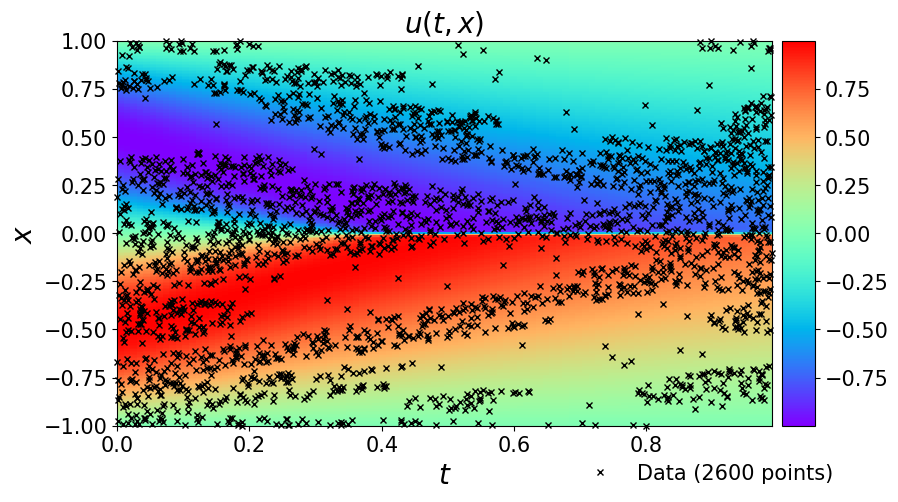

In [ ]:
U_star = griddata(X_star, u_star.flatten(), (X, T), method='cubic')
###### Row 0: u(t,x) ##################    

fig = plt.figure(figsize=(9, 5)) #这里figure是一个figure对象，是一个图形窗口，代表整个图形，设置图形大小为宽9英寸高5 英寸
ax = fig.add_subplot(111) #在图形的1*1网格的第一个位置添加一个子图

#绘图的数据来源
im = ax.imshow(U_star.T, interpolation='nearest', cmap='rainbow', 
              extent=[lb[1], ub[1], lb[0], ub[0]], 
              origin='lower', aspect='auto')   #imshow函数用于显示图像，接受一些参数，第一个参数是图像数据，这里是U_pred的转置；第二个参数是插值方法（用于在像素之间插入新的像素），这里是最邻近插值；
                                                   #第三个参数是颜色映射，这里是用彩虹色图；第四个参数是图像的范围；第五个参数是图像的原点位置，这里表示原点在右下角；第六个参数是图像的纵横比，这里表示调整横纵比以填充整个axes对象
                                                   #最后的结果返回一个axesimage对象，也就是im，可以通过这个对象进一步设置图像的属性


#添加颜色条
divider = make_axes_locatable(ax)  #使用 make_axes_locatable 函数创建了一个 AxesDivider 对象。这个函数接受一个 Axes 对象作为参数，返回一个 AxesDivider 对象。AxesDivider 对象可以用来管理子图的布局，特别是当你需要在一个图的旁边添加另一个图时。
cax = divider.append_axes("right", size="5%", pad=0.10) #使用append_axes方法在原始轴的右侧添加了一个新的轴。append_axes 方法接受三个参数：位置（"right"）、大小（"5%"）和间距（0.10）。在原始轴的右侧添加了一个新的轴，新轴的大小是原始轴的 5%，新轴与原始轴之间的间距是 0.05 英寸
   
cbar = fig.colorbar(im, cax=cax)#使用colorbar方法在新轴上添加了一个颜色条。colorbar 方法接受两个参数：axesimage 对象（im）和新轴（cax）。并记这个颜色条的名字是cbar
cbar.ax.tick_params(labelsize=15) #设置颜色条刻度标签大小，这里bar是之前定义的


#在图上绘制散点图
ax.plot(
    X_f_train[:,1], 
    X_f_train[:,0], 
    'kx', label = 'Data (%d points)' % (X_f_train.shape[0]), 
    markersize = 4,  # marker size doubled
    clip_on = False,
    alpha=1.0
) #在ax上绘制散点图，前两个参数是散点的x坐标和y坐标；kx表示黑色的x（散点形状是x），label是散点的标签，clip_on表示散点可以绘制在轴的边界外
  #新加了一个alpha=1.0用来设置标记的透明度，1.0表示完全不透明  




#设置图的标签、图例、标题和刻度标签
#设置ax子图的x轴的标签为t，y轴的标签为x。这里$t$和$x$是latex格式的文本，用于生成数学公式
ax.set_xlabel('$t$', size=20)
ax.set_ylabel('$x$', size=20)
#设置子图ax的图例，第一个参数用来设置图例的位置，这里表示图例放在上方中央;第二个参数用来设置图例的锚点，接受一个元组，表示x和y坐标，表示把图例的锚点设置在x坐标为0.9，y坐标为-0.05处;frameon=False表示不显示图例的边框;第三个参数设置图例的列数，分为5列；最后一个参数设置图例属性，接受字典，这里表示设置图例字体大小为15；最后返回的leg是一个legend对象，表示图形的图例
ax.legend(
    loc='upper center', 
    bbox_to_anchor=(0.9, -0.05), 
    ncol=5, 
    frameon=False, 
    prop={'size': 15}
)
#设置子图ax的标题为$u(t,x)$，表示latex格式的文本，用于生成数学公式，fontsize=10表示字体大小为20
ax.set_title('$u(t,x)$', fontsize = 20) # font size doubled，两倍化子图标题
ax.tick_params(labelsize=15)#用来设置刻度标签的大小。`tick_params`是`Axes`对象的一个方法，可以用来设置刻度线的属性。在这里，`labelsize=15` 是用来设置刻度标签的字体大小的。


#显示图片
plt.show() #显示所有打开的图形的函数

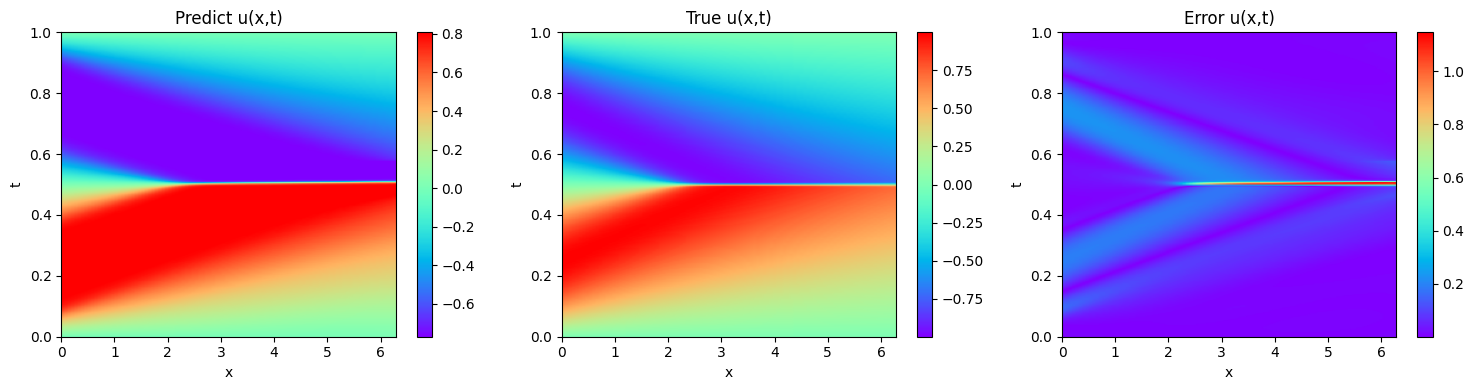

In [ ]:

# 创建一个包含三幅子图的图像
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 绘制第一幅图像
axes[0].imshow(U_pred.T, extent=[0, np.pi*2, 1, 0], aspect='auto', cmap='rainbow')
axes[0].invert_yaxis()
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
axes[0].set_title('Predict u(x,t)')
fig.colorbar(axes[0].images[0], ax=axes[0])

# 绘制第二幅图像
axes[1].imshow(U_star.T, extent=[0,np.pi*2,1,0], aspect='auto', cmap='rainbow') #第一个参数为数据，第二个参数为一个列表，用于设置图像的坐标范围，aspect='auto'表示纵横比自动调整
axes[1].invert_yaxis()
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
axes[1].set_title('True u(x,t)')
fig.colorbar(axes[1].images[0], ax=axes[1])

# 绘制第三幅图像
axes[2].imshow(np.abs(U_pred - U_star).T, extent=[0,np.pi*2,1,0], aspect='auto', cmap='rainbow') #第一个参数为数据，第二个参数为一个列表，用于设置图像的坐标范围，aspect='auto'表示纵横比自动调整
axes[2].invert_yaxis()
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
axes[2].set_title('Error u(x,t)')
fig.colorbar(axes[2].images[0], ax=axes[2])

# 自动调整子图参数，使得子图之间的间距适当
plt.tight_layout()
plt.show()